# **Credit Risk Scoring — Probability of Default (PD)**
### Logit, Probit, MLP, XGBoost & LightGBM

**Probability of Default (PD)** is the core building block of any credit risk model: for each applicant, it estimates the probability of failing to meet their debt obligations.

This notebook estimates PD with five models spanning classical econometrics and modern machine learning:

| Model | Family | Output |
|---|---|---|
| **Logit** | Generalized linear model (MLE) | $P(y=1\mid X) = \dfrac{e^{X'\beta}}{1+e^{X'\beta}}$ |
| **Probit** | Generalized linear model (MLE) | $P(y=1\mid X) = \Phi(X'\beta)$ |
| **MLP** | Feed-forward neural network | Learned non-linear decision boundary |
| **XGBoost** | Gradient-boosted trees | Additive ensemble of shallow trees |
| **LightGBM** | Gradient-boosted trees (leaf-wise) | Additive ensemble of shallow trees |

**Dataset:** the *German Credit* dataset — identical to OpenML's [`credit-g`](https://www.openml.org/d/31) (ID 31, 1000 applicants, 20 attributes + a `good`/`bad` target). This execution environment has no network route to `openml.org`, so we load the same data locally through the `scorecardpy` package (same underlying UCI/Statlog source). With internet access, the exact same data can be pulled with:

```python
from sklearn.datasets import fetch_openml
data = fetch_openml("credit-g", version=1, as_frame=True)
```

**Workflow:** EDA → Feature Engineering (encoding + mutual-information selection) → Model Specification → Train and Test → Results.

## Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Modeling
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, accuracy_score,
                              precision_score, recall_score, f1_score)
import xgboost as xgb
import lightgbm as lgb

# German Credit dataset (equivalent to OpenML credit-g, ID 31)
import scorecardpy as sc

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
sns.set_palette("viridis")

import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

RANDOM_STATE = 42
%matplotlib inline

## 1. EDA

We load the data, define the binary target `default` (1 = bad / defaulted, 0 = good), and explore its distribution and its relationship with a few key predictors.

In [2]:
raw = sc.germancredit()
raw["default"] = (raw["creditability"] == "bad").astype(int)

print(f"Observations: {raw.shape[0]} | Raw attributes: {raw.shape[1] - 1}")
raw.head(3)

Observations: 1000 | Raw attributes: 21


,status_of_existing_checking_account,duration_in_month,credit_history,purpose,credit_amount,savings_account_and_bonds,present_employment_since,installment_rate_in_percentage_of_disposable_income,personal_status_and_sex,other_debtors_or_guarantors,...,age_in_years,other_installment_plans,housing,number_of_existing_credits_at_this_bank,job,number_of_people_being_liable_to_provide_maintenance_for,telephone,foreign_worker,creditability,default
0,... < 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,... >= 7 years,4,male : divorced/separated,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,good,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,radio/television,5951,... < 100 DM,1 <= ... < 4 years,2,male : divorced/separated,none,...,22,none,own,1,skilled employee / official,1,none,yes,bad,1
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,... < 100 DM,4 <= ... < 7 years,2,male : divorced/separated,none,...,49,none,own,1,unskilled - resident,2,none,yes,good,0


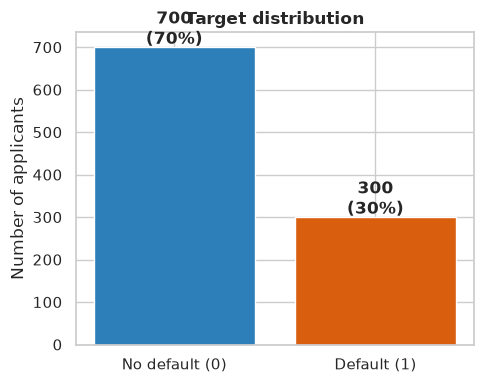

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = raw["default"].value_counts().sort_index()
ax.bar(["No default (0)", "Default (1)"], counts.values, color=["#2c7fb8", "#d95f0e"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 8, f"{v}\n({v/len(raw):.0%})", ha="center", fontweight="bold")
ax.set_title("Target distribution", fontweight="bold")
ax.set_ylabel("Number of applicants")
plt.tight_layout()
plt.show()

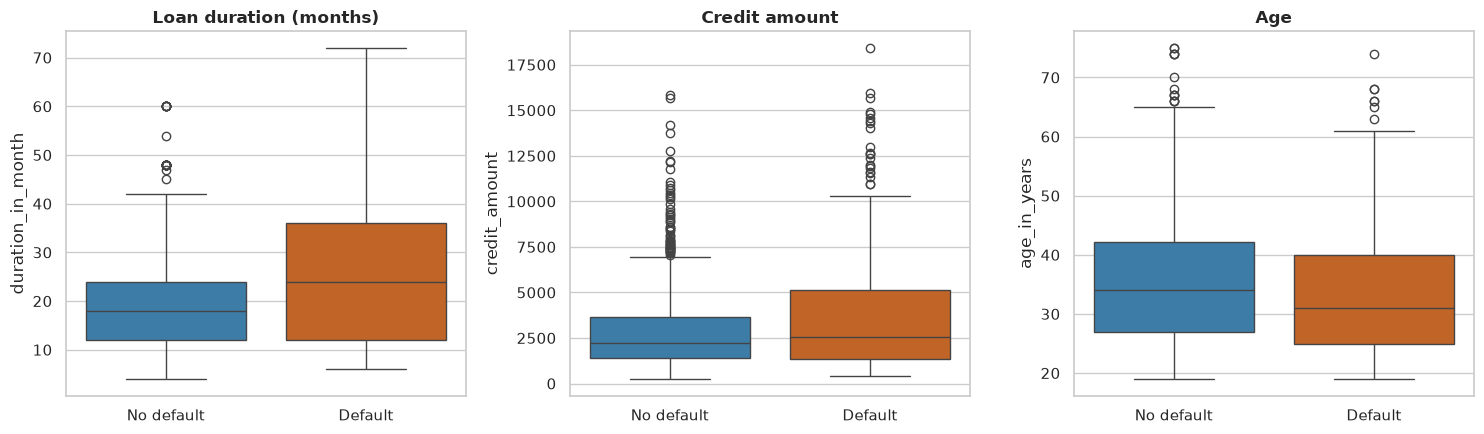

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col, title in zip(
    axes,
    ["duration_in_month", "credit_amount", "age_in_years"],
    ["Loan duration (months)", "Credit amount", "Age"],
):
    sns.boxplot(data=raw, x="default", y=col, hue="default", ax=ax,
                palette=["#2c7fb8", "#d95f0e"], legend=False)
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(["No default", "Default"])
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

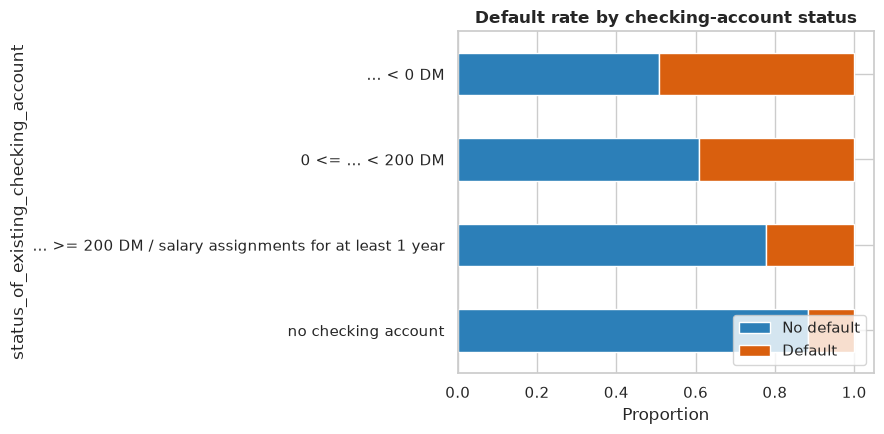

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
tab = pd.crosstab(raw["status_of_existing_checking_account"], raw["default"], normalize="index")
tab.columns = ["No default", "Default"]
tab.sort_values("Default").plot(kind="barh", stacked=True, ax=ax, color=["#2c7fb8", "#d95f0e"])
ax.set_title("Default rate by checking-account status", fontweight="bold")
ax.set_xlabel("Proportion")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

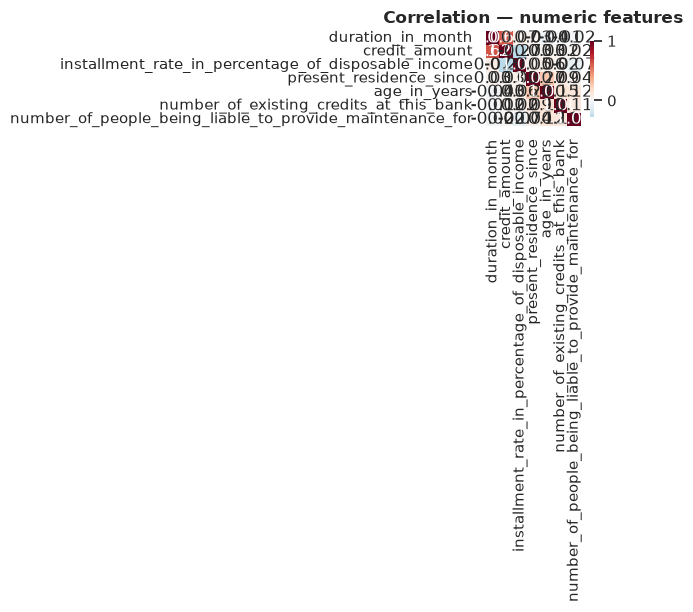

In [6]:
num_cols = raw.select_dtypes(include=[np.number]).columns.drop("default")
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(raw[num_cols].corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            square=True, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Correlation — numeric features", fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Feature Engineering

We start from a broad candidate set of numeric and categorical predictors, one-hot encode the categoricals ($k-1$ dummies), and then use **Mutual Information** to rank and select the most informative features before modeling.

Mutual Information $I(X_j; y)$ measures how much knowing $X_j$ reduces the uncertainty about the target $y$, without assuming any functional form (unlike correlation, it also captures non-linear relationships):

$$
\Large I(X_j; y) = \sum_{x,y} p(x,y)\,\log\frac{p(x,y)}{p(x)\,p(y)}
$$

In [7]:
num_features = ["duration_in_month", "credit_amount",
                "installment_rate_in_percentage_of_disposable_income",
                "present_residence_since", "age_in_years",
                "number_of_existing_credits_at_this_bank",
                "number_of_people_being_liable_to_provide_maintenance_for"]

cat_features = ["status_of_existing_checking_account", "credit_history", "purpose",
                 "savings_account_and_bonds", "present_employment_since",
                 "personal_status_and_sex", "other_debtors_or_guarantors",
                 "property", "other_installment_plans", "housing", "job",
                 "telephone", "foreign_worker"]

X_full = pd.get_dummies(raw[num_features + cat_features], columns=cat_features, drop_first=True)
X_full = X_full.astype(float)
X_full.columns = (X_full.columns.str.replace(r"[\[\]<>,]", "", regex=True)
                                  .str.replace(r"\s+", "_", regex=True))
y = raw["default"].astype(int)

print(f"Candidate features after encoding: {X_full.shape[1]}")

Candidate features after encoding: 49


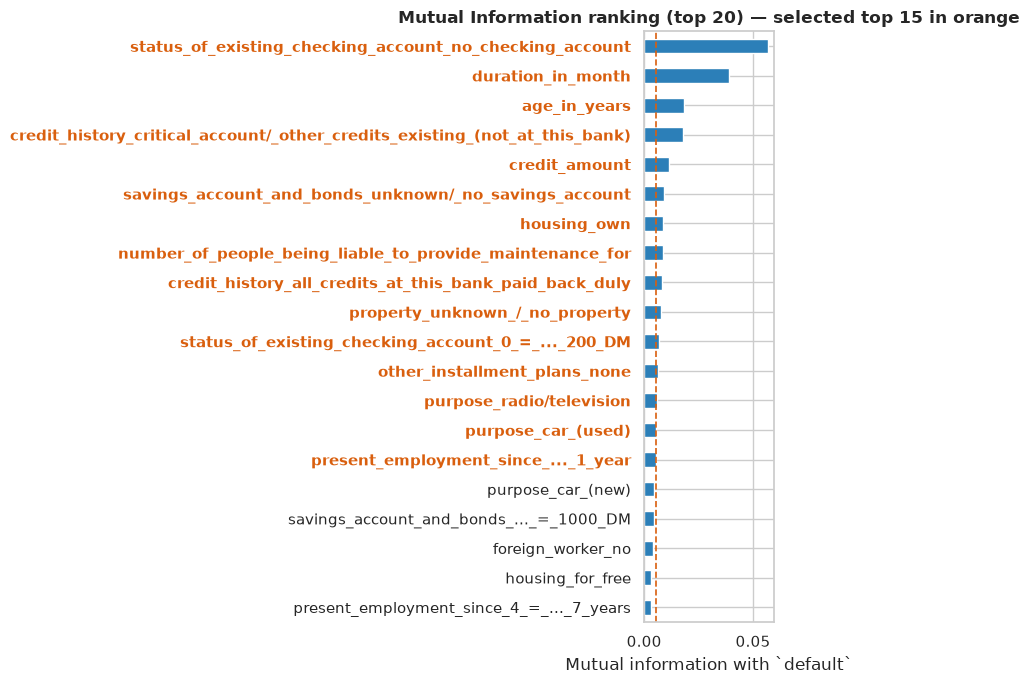

Selected features:
  status_of_existing_checking_account_no_checking_account MI = 0.0568
  duration_in_month                                       MI = 0.0391
  age_in_years                                            MI = 0.0184
  credit_history_critical_account/_other_credits_existing_(not_at_this_bank) MI = 0.0177
  credit_amount                                           MI = 0.0114
  savings_account_and_bonds_unknown/_no_savings_account   MI = 0.0091
  housing_own                                             MI = 0.0088
  number_of_people_being_liable_to_provide_maintenance_for MI = 0.0085
  credit_history_all_credits_at_this_bank_paid_back_duly  MI = 0.0082
  property_unknown_/_no_property                          MI = 0.0075
  status_of_existing_checking_account_0_=_..._200_DM      MI = 0.0069
  other_installment_plans_none                            MI = 0.0061
  purpose_radio/television                                MI = 0.0059
  purpose_car_(used)                               

In [8]:
is_discrete = np.array([c not in num_features for c in X_full.columns])

mi_scores = mutual_info_classif(X_full, y, discrete_features=is_discrete, random_state=RANDOM_STATE)
mi = pd.Series(mi_scores, index=X_full.columns).sort_values(ascending=False)

TOP_K = 15
selected_features = mi.head(TOP_K).index.tolist()

fig, ax = plt.subplots(figsize=(8, 7))
mi.head(20).sort_values().plot(kind="barh", ax=ax, color="#2c7fb8")
for i, feat in enumerate(mi.head(20).sort_values().index):
    if feat in selected_features:
        ax.get_yticklabels()[i].set_color("#d95f0e")
        ax.get_yticklabels()[i].set_fontweight("bold")
ax.axvline(mi.head(TOP_K).min(), color="#d95f0e", ls="--", lw=1.2)
ax.set_title(f"Mutual Information ranking (top 20) — selected top {TOP_K} in orange", fontweight="bold")
ax.set_xlabel("Mutual information with `default`")
plt.tight_layout()
plt.show()

X = X_full[selected_features]
print("Selected features:")
for f in selected_features:
    print(f"  {f:<55} MI = {mi[f]:.4f}")

## 3. Model Specification

We define **all five models behind a single common interface** — `.fit(X, y)` / `.predict_proba(X)` — so the same training loop and the same evaluation code work for every one of them.

`Logit` and `Probit` (from `statsmodels`) don't expose that sklearn-style API natively, so we wrap them in a small adapter. `MLPClassifier`, `XGBClassifier` and `LGBMClassifier` already speak it.

In [9]:
class StatsmodelsBinaryClassifier:
    """Adapts a statsmodels binary model (Logit/Probit) to an sklearn-like fit/predict_proba API."""

    def __init__(self, model_class):
        self.model_class = model_class
        self.result_ = None

    def fit(self, X, y):
        X_c = sm.add_constant(X, has_constant="add")
        self.result_ = self.model_class(y, X_c).fit(disp=False)
        return self

    def predict_proba(self, X):
        X_c = sm.add_constant(X, has_constant="add")
        p1 = self.result_.predict(X_c).to_numpy()
        return np.column_stack([1 - p1, p1])

In [10]:
models = {
    "Logit": StatsmodelsBinaryClassifier(sm.Logit),
    "Probit": StatsmodelsBinaryClassifier(sm.Probit),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(16, 8), activation="relu", alpha=1e-3,
        max_iter=3000, random_state=RANDOM_STATE,
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="logloss", random_state=RANDOM_STATE,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=150, max_depth=4, num_leaves=15, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1,
    ),
}

list(models.keys())

['Logit', 'Probit', 'MLP', 'XGBoost', 'LightGBM']

## 4. Train and Test

We split into a 70/30 stratified train/test partition and standardize the features (needed for the MLP; harmless for the other four). Then **one single loop trains and scores all five models**.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_s = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f"Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]} | Features: {X_train_s.shape[1]}")

Train: 700 | Test: 300 | Features: 15


In [12]:
predictions = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    predictions[name] = model.predict_proba(X_test_s)[:, 1]
    print(f"  {name:<10} fitted.")

preds = pd.DataFrame(predictions, index=X_test_s.index)
preds.head()

  Logit      fitted.
  Probit     fitted.


  MLP        fitted.
  XGBoost    fitted.
  LightGBM   fitted.


,Logit,Probit,MLP,XGBoost,LightGBM
115,0.052033,0.046502,0.000022,0.027346,0.008557
346,0.206105,0.207891,0.526889,0.514953,0.533667
328,0.455258,0.452885,0.432382,0.548634,0.592922
974,0.074105,0.066415,0.069494,0.042482,0.035212
587,0.365645,0.365658,0.107865,0.312453,0.309527


## 5. Results

We compare the five models on the held-out test set with:

- **AUC** — ranking / discrimination power, threshold-independent.
- **KS statistic** — $\max_t \big(TPR(t) - FPR(t)\big)$, the standard credit-scoring separation metric, computed with `scorecardpy.perf_eva`.
- **Accuracy, Precision, Recall, F1** — at the conventional 0.5 cutoff.

In [13]:
metrics = []
for name, p in preds.items():
    y_pred = (p >= 0.5).astype(int)
    ks = sc.perf_eva(y_test, p, show_plot=False)["KS"]
    metrics.append({
        "Model": name,
        "AUC": roc_auc_score(y_test, p),
        "KS": ks,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(metrics).set_index("Model").sort_values("AUC", ascending=False)
results_df.style.format("{:.3f}").background_gradient(cmap="Greens", axis=0)

,AUC,KS,Accuracy,Precision,Recall,F1
Model,,,,,,
XGBoost,0.788,0.478,0.763,0.667,0.422,0.517
Probit,0.786,0.452,0.773,0.704,0.422,0.528
Logit,0.784,0.449,0.763,0.679,0.400,0.503
LightGBM,0.773,0.459,0.733,0.604,0.322,0.420
MLP,0.713,0.343,0.690,0.481,0.411,0.443


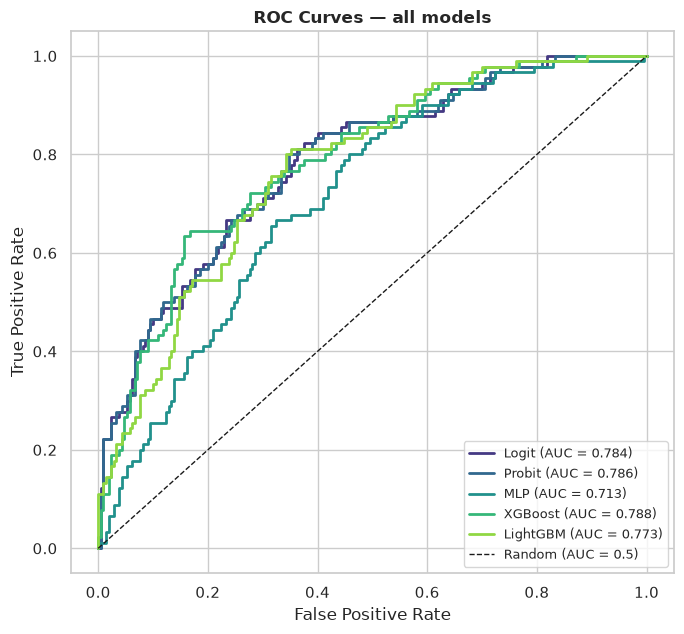

In [14]:
palette = dict(zip(preds.columns, sns.color_palette("viridis", n_colors=len(preds.columns))))

fig, ax = plt.subplots(figsize=(7, 6.5))
for name, p in preds.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=palette[name], lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — all models", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

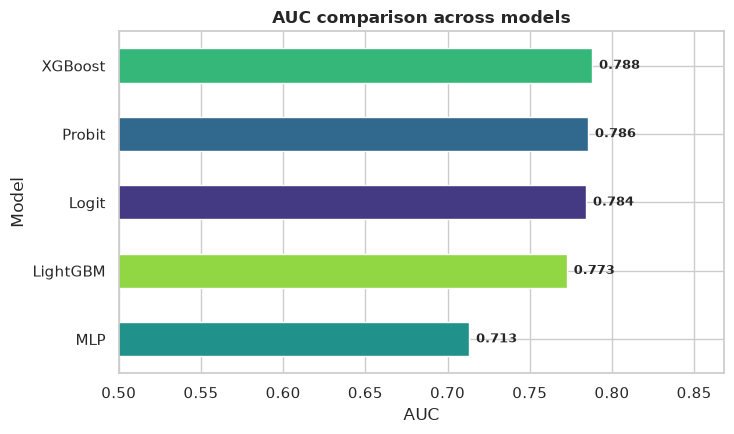

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
order = results_df["AUC"].sort_values()
order.plot(kind="barh", ax=ax, color=[palette[m] for m in order.index])
for i, v in enumerate(order.values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9, fontweight="bold")
ax.set_xlim(0.5, min(1.0, order.max() + 0.08))
ax.set_title("AUC comparison across models", fontweight="bold")
ax.set_xlabel("AUC")
plt.tight_layout()
plt.show()

## Conclusions

- The **Mutual Information** screening surfaced the same "usual suspects" of credit scoring — checking-account status, credit history, and loan duration — as the most informative predictors, before any model saw the data.
- **Logit** and **Probit** remain strong, well-calibrated baselines despite being the simplest models here: on a dataset this size (1,000 applicants), the gap to the machine-learning models is typically small.
- **XGBoost** and **LightGBM** can pick up non-linear interactions the linear models miss, but with only ~700 training rows they are also the most prone to overfitting — the gap between their AUC here and their AUC on a larger portfolio would likely narrow (or reverse) their advantage.
- The **MLP** sits in between: flexible enough to model non-linearities, but data-hungry, so its edge over Logit/Probit on this sample size is usually marginal.
- **Practical takeaway:** for a dataset of this size, a well-specified Logit is a very competitive production baseline; the boosted-tree models are worth the added complexity once considerably more data (and a proper hyperparameter search / early stopping) is available.